In [1]:
import torch
import math
import torch.nn.functional as F
import matplotlib.pyplot as plt

In [2]:
class BigramLanguageModel:
    def print_words_info(self):
        print(f"{50 * '-'}")

        print(f"Num of word: {len(self.words)}")
        print(f"Min length: {[min(len(w) for w in self.words)]}")
        print(f"Max length: {[max(len(w) for w in self.words)]}")

        print(f"{50 * '-'}")

    def _open_file(self) -> list[str]:
        with open("name.txt", "r", encoding="utf-8") as file:
            return file.read().splitlines()

    def __init__(self) -> None:
        self.words: list[str] = self._open_file()
        self.chars: list[str] = sorted(set("".join(self.words)))  # words 中所有的字符

        self.stoi: dict[str, int] = {s: i + 1 for i, s in enumerate(self.chars)}
        self.stoi["."] = 0  # 第一个字符是 '.'

        self.itos = {i: s for s, i in self.stoi.items()}

        """
        26 个字母 + ., 因而 27 * 27
        初始值为 0
        """
        self.N = torch.zeros(27, 27)  # 样本总量
        for word in self.words:
            """
            先查word, 找到连续字符, 再查 stoi, 再匹配 N 中坐标, 对应位置 +1
            """
            word_ = ["."] + list(word) + ["."]
            for ch1, ch2 in zip(word_, word_[1:]):
                ix1 = self.stoi[ch1]
                ix2 = self.stoi[ch2]
                self.N[ix1, ix2] += 1

    def cal_likelihood_loss_counting_method(
        self, n_example: int, penalty=0
    ):  # 对前 n_example 个 word 计算 loss 的
        sum_likeli: float = 0
        count: int = 0

        """
        当 penalty 很大时, 二元字符组原来的频次几乎可以忽略, 如
        fa = 2+10000, fb = 35 + 10000, ... fn = 109 + 10000 (共 N 个)
        p(fa) = (2+10000) / sum(2+10000, 3+10000, ...), 其值将接近 1 / N
        概率分布区趋向平均, 平滑
        """

        N_with_penalty = self.N
        N_with_penalty += penalty
        probN_count = N_with_penalty / N_with_penalty.sum(
            1, keepdim=True
        )  # 每个元素 / 元素所在行的和

        for word in self.words[:n_example]:
            chs = ["<.>"] + list(word) + ["<.>"]
            for ch1, ch2 in zip(chs, chs[1:]):
                ix1 = self.stoi[ch1]
                ix2 = self.stoi[ch2]

                sum_likeli += math.log(probN_count[ix1, ix2])  # 对数
                count += 1
        """
        math.log() 的参数是 x, 返回值是 y
        sum_likeli = math.log(p1) + math.log(p2) + ... + math.log(pn) = math.log(p1 * p2 * ... * pn)
        由于 p1, p2 ... 均 < 1, 因而 sum_likeli 是负数, 因而取反作为最终结果
        如果预期正确的字符 a 的概率是0.8, 那么错误的概率就是0.2
        p1, p2 ... 越大, 即正确率越高, 那么 -log(p1 * p2 * ... * pn) 就越小, 可以说 loss 越小, 模型质量越高
        """
        loss = -sum_likeli / count  # 负对数似然
        print(f"loss_counting_method: {loss:.4f}")  # 损失函数

    def cal_likelihood_loss_neural(self, n_example: int):
        xs = []
        ys = []
        for word in self.words[:n_example]:
            word_ = ["<.>"] + list(word) + ["<.>"]
            for ch1, ch2 in zip(word_, word_[1:]):
                ix1 = self.stoi[ch1]
                ix2 = self.stoi[ch2]
                xs.append(ix1)
                ys.append(ix2)
                # print(ch1, ch2)

        xs = torch.tensor(xs, dtype=torch.long)
        ys = torch.tensor(ys, dtype=torch.long)

        # print(f"xs: {xs}")
        # print(f"ys: {ys}")

        """
        只有一个是“热”的（值为 1），其余都是“冷”的（值为 0）
        假设你有 5 个可能的字符 [a, b, c, d, e]，它们的索引分别是 [0, 1, 2, 3, 4]
            数字 0 的 One-hot 是：[1, 0, 0, 0, 0]
            数字 3 的 One-hot 是：[0, 0, 0, 1, 0]
        """

        xenc = F.one_hot(xs, num_classes=27).float()
        # print(f"xenc shape: {xenc.shape}")
        # print(f"xenc value: {xenc}")

        g = torch.Generator().manual_seed(214783647 + 1)
        """
        w 是符合正态分布的采样, 取值范围是(-∞,+∞), 但其表示的是某个二元组的权重
        """
        w = torch.randn(27, 27, generator=g, requires_grad=True)

        self._fine_tune(xenc, w, n_example, ys)

    def _get_prob_log_softmax(self, xenc: torch.Tensor, w: torch.Tensor):
        """
        这里有点类似过滤, w 本来是 27 * 27
        经过 xenc @ 后, 仅仅把 xenc 那几行抽出来了, 其它行都被过滤掉了
        """

        logits = xenc @ w  # 强制认为它在对数空间
        # print(f"logits shape: {logits.shape}")
        # print(f"logits value: {logits}")
        """
        softmax
        """

        counts = logits.exp()  # > 0, 正值化
        return counts / counts.sum(1, keepdim=True)  # 归一化

    def _fine_tune(
        self, xenc: torch.Tensor, w: torch.Tensor, n_example: int, ys: torch.Tensor
    ):
        n_char = ys.nelement()
        for i in range(500):
            probs = self._get_prob_log_softmax(xenc, w)

            """
            每一行的概率的平均值
            probs[torch.arange(n_char), ys] 得到是所有正确答案组成的一个tensor1
            tensor1.log() 返回 torch.Tensor类型的 [log(tensor1[0]),log(tensor1[1]), ...] : list
            mean() 求平均, 分子为 log(tensor1[0])+ log(tensor1[1])+... = log(tensor1[0] * tensor1[1] * tensor1[2] * ...)
            """

            data_loss = -probs[torch.arange(n_char), ys].log().mean()
            reg_loss = 0.01 * (w**2).mean()  # penalty
            total_loss = data_loss + reg_loss
            # print(f"loss_neural: {loss:.4f}")

            w.grad = None  # type of w is troch.tensor

            total_loss.backward()
            """
            loss = -probs[torch.arange(n_char), ys].log().mean()
                这里 ys 的元素并不是所有组合的下标, 所有存在的组合的下标
                ys 整体是所有正确答案的下标的组合
                对于越高频的组合, 其会在ys 中出现多次,例如 ys 中会包含 1000 个 an 的下标
                假设  an, am, ad 的频次比较高,对于 aj, aq 的这种不存在的下标, ys 中不会出现
                sum(p) = log(p(an)) + ..1000个.. + log(p(an)) +
                        log(p(am) + ..100个.. + log(p(am)) +
                        log(p(ad)) + ..20个.. + log(p(ad)) + ...
                此时 loss = sum(p)  / N
                如何才能让 loss 减小? 那就是让 p(an) 尽可能的接近1
                模型为了降低 loss, 会极端使 w 中 an 的权重 W_an 变大, 进而其它的权重W减小(为负值), 本质而言使W 的绝对值变大, 使模型变得激进

                对于出现频次较多的组合, 模型会将其权重W配置的极大,如 an:100, am:80, ad:20 ...
                而频次较低的组合, 将其权重W配置的极小如 aj:-5, aq: -8, ...
                直接表现就是它认为所有的a后面一定是n, 不会再预测出其它值, 哪怕他们有一定的可能性

            当加上了 penalty 与 w^ 2相关, 为了减小 loss, 模型同时会趋向于减小 w, 本质而言使模型的绝对值减小
            模型需要在数据的压力 (Gradient from Data Loss) 和 正则化的压力 (Gradient from Penalty) 之间取得平衡
            """

            if w.grad is not None:
                w.data += (-50) * w.grad

        print(f"loss_neural: {total_loss:.4f}")


b = BigramLanguageModel()

# n_example = len(b.words)
# b.cal_likelihood_loss_counting_method(n_example)
# b.cal_likelihood_loss_neural(n_example)

In [3]:
words = b.words

In [5]:
block_size = 3
embedding_dim = 10
n_neural = 200

In [6]:
X = []
Y = []
for word in words:
    # print(word)
    context: list[int] = [
        0
    ] * block_size  # 初始值 [0,0,0 ...],对应着 stoi 中 字符 '.' 的下标
    for ch in word + ".":
        ix = b.stoi[ch]
        X.append(context)
        Y.append(ix)

        context = context[1:] + [ix]
X = torch.tensor(X)
Y = torch.tensor(Y)

In [8]:
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(27, embedding_dim, generator=g)  # 查找表: LookUp Table

# n_neural 个神经元, 每个有 block_size * n_embedding 个参数(需要接收每个样本的超参数)
# W1 = torch.randn(block_size * embedding_dim, n_neural, generator=g)
# b1 = torch.randn(W1.shape[1], generator=g)  # n_embedding 个 bias

W1 = torch.randn(block_size * embedding_dim, n_neural, generator=g) * 0.15
b1 = torch.randn(W1.shape[1], generator=g) * 0.01


# W2 = torch.randn(n_neural, 27, generator=g)
# b2 = torch.randn(W2.shape[1], generator=g)
W2 = torch.randn(n_neural, 27, generator=g) * 0.01
b2 = torch.randn(W2.shape[1], generator=g) * 0.1

parameters = {C, W1, b1, W2, b2}

In [ ]:
# Kaiming Initialization and Batch Normalization
g = torch.Generator().manual_seed(2147483647)
C = torch.randn(27, embedding_dim, generator=g)  # 查找表: LookUp Table

# n_neural 个神经元, 每个有 block_size * n_embedding 个参数(需要接收每个样本的超参数)
fan_in = block_size * embedding_dim
W1 = (
    torch.randn(block_size * embedding_dim, n_neural, generator=g)
    * (5 / 3)
    / fan_in**0.5
)
b1 = torch.randn(W1.shape[1], generator=g)


W2 = torch.randn(n_neural, 27, generator=g)
b2 = torch.randn(W2.shape[1], generator=g)

# batch normalization
bn_gain = torch.ones(1, n_neural)
bn_bias = torch.zeros(1, n_neural)
# beta =

parameters = [C, W1, b1, W2, b2, bn_gain, bn_bias]

In [9]:
step = 200000
batch_size = 32

In [ ]:
for p in parameters:
    p.requires_grad = True

lossi = []
for i in range(step):
    """
    X.shape[0], X 共多少行, 多少个样本
    随机数最小值是0, 最大值不超过行数
    共batch_size个随机数
    """
    assert isinstance(X, torch.Tensor)
    ix = torch.randint(0, X.shape[0], (batch_size,))

    """
    全批量（Full Batch）：算出的下降方向最准，但每次计算量太大(几万个样本)，走一步太慢
    小批量（Mini-batch）：每次只算 batch_size 个样本，计算速度非常快；同时这 batch_size 个样本又能大致代表整体数据的特征，算出来的方向大体上是往山谷（最低点）走的
    """

    emb = C[
        X[ix]
    ]  # C[X]:  X.shape[0](行数) * block_size * n_embedding, 共 X.shape[0] 组, 随机取 ix 组
    hidelayer_dim = block_size * embedding_dim
    # emb.shape[0] * hidelayer_dim,  每行 hidelayer_dim 个元素, 每 n_embedding_dim 个元素对应 1 个字符, 对应着 block_size 个连续的字符(一个样本)
    hpreact = (
        emb.view(-1, hidelayer_dim) @ W1
    )  # + b1 # hpreact - hpreact.mean(0, keepdim=True) 会抵消掉 b1
    """
    hpreact - hpreact.mean(0, keepdim=True)
    hpreac 的 shape 是 batch_size * n_neural
    hpreact.mean(0, keepdim=True) 的shape 是 1 * n_neural
    pytorch 会对后者拉伸, 即沿行复制 batch_size 次, 严格的说是 batch_size - 1 次
    """

    hpreact = (hpreact - hpreact.mean(0, keepdim=True)) / hpreact.std(0, keepdim=True)
    hpreact = bn_gain * hpreact + bn_bias
    h = torch.tanh(hpreact)

    logits = h @ W2 + b2

    for p in parameters:
        p.grad = None

    loss = F.cross_entropy(logits, Y[ix])  # 随机取 ix 组
    lossi.append(loss.item())
    loss.backward()

    learn_rate = 0.1 if i < 10000 else 0.01
    for p in parameters:
        if p.grad is not None:
            p.data += -learn_rate * p.grad
    # break
print(f"loss: {loss}")

loss: 2.055699110031128


**emb.view(-1, hidelayer_dim)**
- 行表示共`batch_size`个样本, 列表示共每个样本有`block_size * embedding_dim`个特征
- 每个样本的所有特征会依次输入给`W1`的每个神经元
  - 样本0输入给神经元0得到 hpreact_00(这是神经元0对样本0的`block_size * embedding_dim`得到的综合特征), 样本0输入给神经元1得到 hpreact_01, ...
  
**hpreact**
- hpreact 的列表示当前神经元对所有`batch_size`个样本的原始特征计算后得到的综合特征,每个元素对应一个样本的综合特征
- 对列压缩则得到当前神经元评估的综合特征的均值或方差(取决于调用函数)

---

tensor 在内存上是连续的, 本质都是一维的, 所谓的 shape 仅仅是逻辑上的变化

vocab_size = 27

X.shape = n * block_size, n = words 中所有字母的数量(重复的也算), X 中的元素不是字母, 而是字母对应的索引(int) [0,vocab_size - 1]

C.shape = vocab_size * embedding_dim, 每一行都有 embedding_dim 个参数(float), 相当于 embedding_dim 个特征

**C[X] 究竟在做什么?**

```c++
// 伪代码
// 遍历的是 X, 拷贝的是 C的内存
for (int i = 0; i < n; ++i) {
    for (int j = 0; j < block_size; ++j) {
        int vocab_idx = x[i][j]; // 非字母, 而是字母的索引, 范围是 0~26
        // 将对应的嵌入向量拷贝到输出张量的正确位置
        memcpy(&output[i][j][0], &C[vocab_idx][0], embedding_dim * sizeof(float)); // embedding_dim * sizeof(int), 逻辑上就是取了一行
    }
}
```
**如果把output 的逻辑结构当成二维看, 那么 output 的逻辑结构(shape)其实和 X 是一模一样的, 差异在于 X 的元素是int, 而 output 的元素是数组**

**以位置[i][j]为例, output 中 [i][j] 位置的元素-数组就是 C 中的行, 行号就是就是 X 中 [i][j] 位置的元素(字母索引)**

如果是一维
```c++
// X_train: [10000][3], ix: [32], output: [32][3]
for (int i = 0; i < 32; ++i) {
    int row_idx = ix[i]; // 比如第 5 行
    // 拷贝一整行数据（包含 block_size 个字母索引）
    memcpy(&output[i][0], &X_train[row_idx][0], 3 * sizeof(int));
}
```

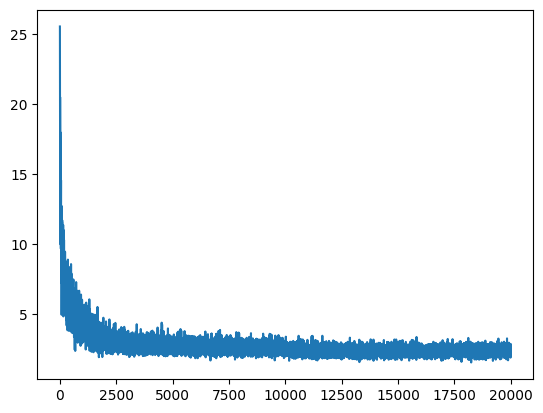

In [ ]:
# W2, b2 保持初始值
plt.plot(lossi)

上图是`W2, b2`保持初始值状态下 `loss` 的变化曲线图

下图是优化`W2, b2`之后的结果
```python
W2 = torch.randn(n_neural, 27, generator=g) * 0.01
b2 = torch.randn(W2.shape[1], generator=g) * 0.1
```
为什么要修复?

默认状态下, W2, b2 都是随机的, 它并不知道正确的答案是什么, 因此可能会被错误的答案分配过高的权重, 进而导致初始学习时, 模型一直在想办法将 loss 从 24 降低到 4, 这是无效的学习

事实上, 在初始状态下, 模型应该是无知的, 它应该平等的看待任何选项, 因而, 我们人为的将`W2, b2`调整为0, 进而使权重`logits`接近 0, 即每个选项的概率都接近 1/27

从图中也能看到, 优化后, loss 直接从3.25 开始下降

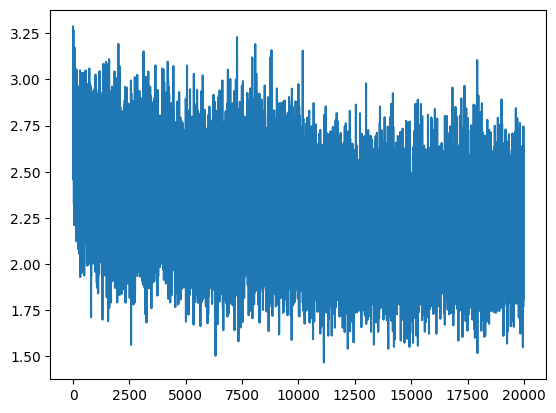

In [ ]:
# W2, b2 手动优化(缩减)
plt.plot(lossi)

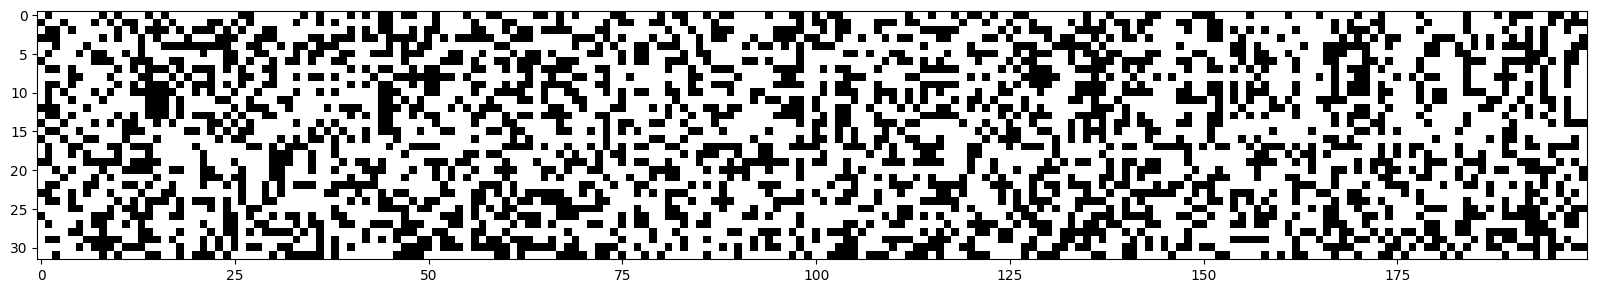

In [ ]:
# W1, b1初始状态(完全依赖随机值)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest")

图中纵坐标是当前 batch 的序列号, 横轴是神经元的序列号


```python
h.abs() > 0.99 == True, imshow 认为是1, black
否则, false, imshow 认为是 0, white

tanh 函数类似
def tanh(self):
        e2x = np.exp(2 * self.data)
        v_tanh = (e2x - 1) / (e2x + 1)
        out = Value(v_tanh, _children=(self,), _op="tanh")
        def _backward():
            self.grad += out.grad * (1 - v_tanh**2)  #  out.grad * (1 - (tanhx)^2)
        out._backward = _backward
        return out
```
`v_tanh`即`Tensor`的实际值


$|v\_tanh| > 0.99, (1 - v\_tanh**2) \approx 0, 导致 self.grad \approx 0$, 那么整个 `back_grad` 到这里就会中断, 无法被激活
$|v\_tanh| == 0, (1 - v_tanh**2) == 1$, `grad` 会直接穿透该层

而 `p.data += -learn_rate * p.grad`

则 如果一个神经元的所有样本 (当前 batch) 的 abs 值为 1, 即 `grad` 均为 0, 则意味着该神经元在当前 batch 永远无法被激活, 无法学习任何内容



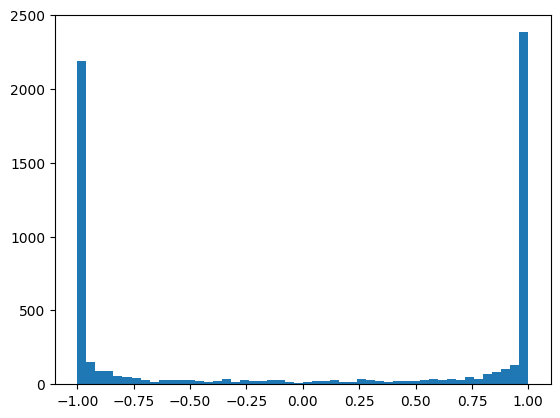

In [ ]:
# W1, b1初始状态(完全依赖随机值)
# ; 不显示数据, 仅图像
# 50 表示把横坐标切分成 50 个均匀的桶
plt.hist(h.view(-1).detach().cpu().numpy(), 50);

横轴是 `h` 值, 即 Tensor 中实际存储的值, 纵轴是分布在该 h 值附近的的元素的数量

元素总数:` batch_size * hidden_layer_n`, 而 `hidden_layer_n = block_size * embedding_n`

从图中可以看出, 大量的元素分布在 1 和 -1, 意味着许多神经元会出现无效学习的情况

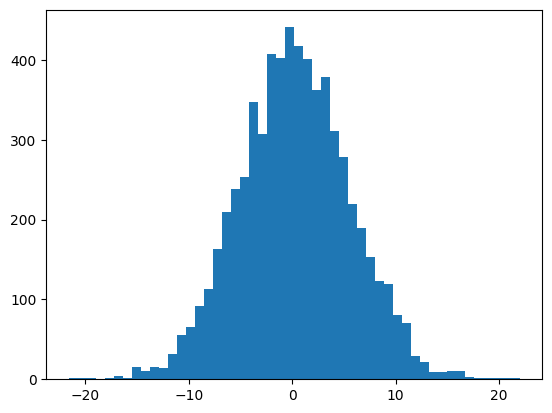

In [ ]:
# W1, b1初始状态(完全依赖随机值)
plt.hist(hpreact.view(-1).detach().cpu().numpy(), 50);

横轴是 `hpreact` 值, 即 Tensor 中实际存储的值, 纵轴是分布在该 `hpreact` 值附近的元素的数量

元素总数:` batch_size * hidden_layer_n`, 而 `hidden_layer_n = block_size * embedding_n`


$tanh(\pm2) \approx 1$, 这也是`h`大量分布在 $\pm 1$的原因

进一步思考
```python
# p 是 parameters 的元素, 包括 W1
# 学习率过大可能导致 W1 过大
# 进而导致 hpreact 过大, 进而导致 h 趋向于1, 导致神经元无法被激活, 被破坏, 称为死亡神经元, 无法学习
p.data += -learn_rate * p.grad 
hpreact = emb.view(-1, hidelayer_dim) @ W1 + b1
```


上面三张图是`W1, b1`初始状态(完全依赖随机值)时的分布图

下面三张图是`W1, b1`优化后的分布图
```python
W1 = torch.randn(block_size * embedding_dim, n_neural, generator=g) * 0.15
b1 = torch.randn(W1.shape[1], generator=g) * 0.01
```
可以看出来, `h` 的的分布相对比较均匀, 并且不会大量出现 `v_tanh > 0.99`的情况, 即死亡神经元极少

`hpreact`也大都分布在`[-2, 2]` 的范围内

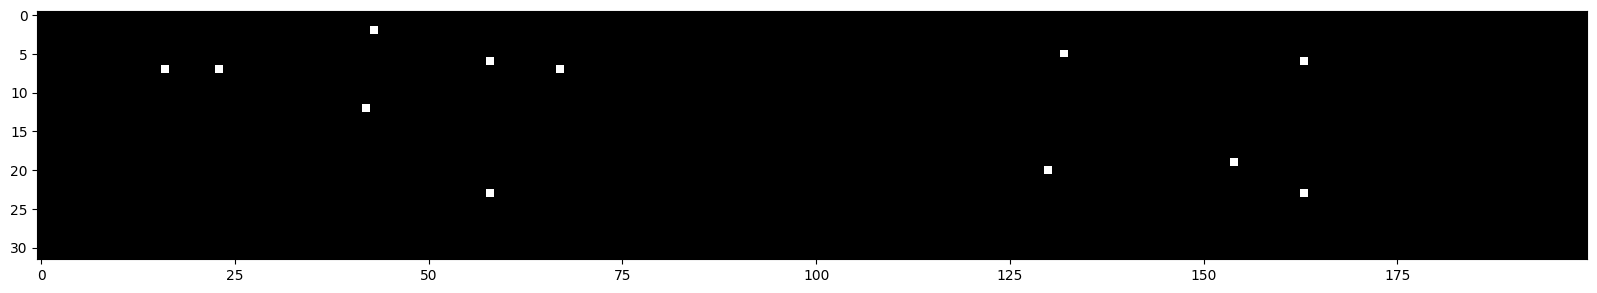

In [ ]:
# W1, b1 手动优化(缩减)
plt.figure(figsize=(20, 10))
plt.imshow(h.abs() > 0.99, cmap="gray", interpolation="nearest")

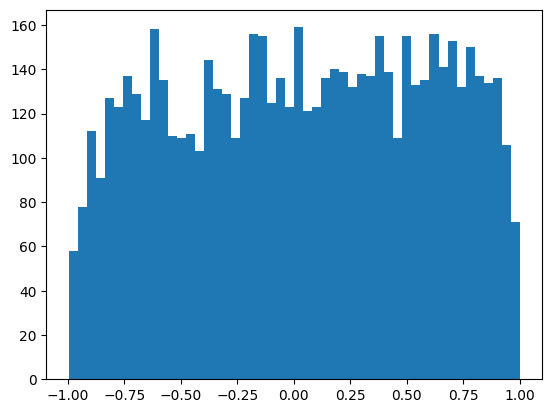

In [ ]:
# W1, b1 手动优化(缩减)
plt.hist(h.view(-1).detach().cpu().numpy(), 50);

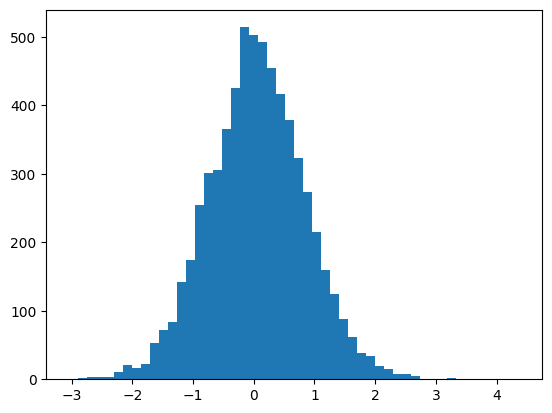

In [ ]:
# W1, b1 手动优化(缩减)
plt.hist(hpreact.view(-1).detach().cpu().numpy(), 50);

```python
x = torch.randn(1000, 10)
```

这里 10 可以说是 10 个维度, 10 个参数, 但准确的说是 10 个神经元特征

比如描述一个西瓜, 用 "大","绿","甜","水果" 4 个特征来描述

用一个新的例子谈谈 Kaiming Initialization 和 Batch Normalization

x_mean: 0.0113, x_std: 1.0046
y_mean-0.0055, y_std: 3.2085


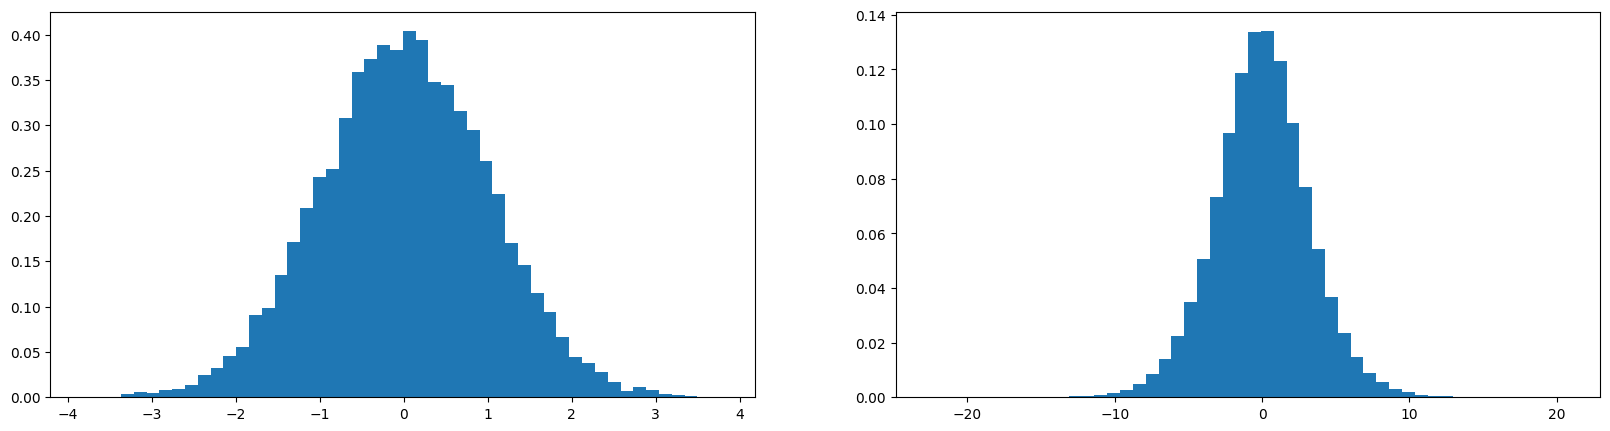

In [ ]:
x = torch.randn(1000, 10)  # 1000 个样本, 每个样本 10 个维度
w = torch.randn(10, 200)  # 200 个神经元, 每个神经元接受 10 个参数
y = x @ w
print(f"x_mean: {x.mean():.4f}, x_std: {x.std():.4f}")
print(f"y_mean{y.mean():.4f}, y_std: {y.std():.4f}")

plt.figure(figsize=(20, 5))
plt.subplot(121)
plt.hist(x.view(-1).detach().cpu().numpy(), 50, density=True)
plt.subplot(122)
plt.hist(y.view(-1).detach().cpu().numpy(), 50, density=True);

从输出结果来看, `x_std: 1.0046`, 而`y_std: 3.2085`,这说明经过了一层传递, 方差变大, `y(Tensor)` 变得更加分散,导致 `hpreact` 分布的范围更广,而不是聚集在 [-2, 2] 的范围, 下面推导如何确保方差不会逐层扩散

论文 \<<Delving Deep into Rectifiers: Surpassing Human-Level Performance on ImageNet Classification\>> 对这个问题进行了研究,下面阐述核心内容

$
\small
已知: Var(x_i) == Var(w_i) == 1 \\
\because Var(y_{00}) = Var(x_{00}) * Var(w_{00}) + Var(x_{01}) * Var(w_{10}) + Var(x_{02}) * Var(w_{20}) + ... + Var(x_{0n}) * Var(w_{n0}) \# 这里仅以 y_{00}为例 \\
\because 对于标准差为 1 的正态分布而言, 乘积的方差等于方差的乘积(证明稍麻烦, 这里不详写) \\
\therefore Var(y) = n * Var(x) * Var(w) \\
为了确保 Var(y) = 1 (方差不扩散), 则需要 \\
Var(w) = 1 / n \\
已知: Var(s * q) = s^2 * Var(q) (s 是常量, 很容易证明, 不赘述)\\
若 Var(w_{new}) = 1 / n\\
则 Var(w_{new}) = ({1 / \sqrt{n}})^2 * Var(w_{old}) (已知: Var(w_{old}) == 1)\\
\therefore w_{new} = (1 / \sqrt{n}) * w_{old} \\
最后来看 n 是什么\\
上一层有 n 个神经元就会输出 n 个特征 \\
就当前层而言, 这里 n 为样本的参数数量, 是当前层神经元可以接收的参数的数量, 即上一层有 n 个神经元, 这一层的每个神经元都必须能够接收 n 个参数, 因而 n 可解释为输入神经元的数量, 其标准名称为 fan\_in \\
当前层有 m 个神经元就会输出 m 个特征, 因而 m 可解释为输出神经元的数量, 其标准名称为 fan\_out, 显然, 下一层的每个神经元都必须要能接受 m 个特征(m个参数) \\
$

**激活函数**

神经网络中的线性激活函数特指 k = 1, b = 0 的线性函数, 因而不会对方差有任何影响, 标准差缩减保持原值即可

${\color{yellow}非线性激活函数}$

${\color{green}ReLU}$

假设当前层输入的方差是 $Var(x)$，这一层有 $n$ 个输入神经元（即 fan_in）。数据穿过这一层（矩阵运算 + ReLU）经历了极其精确的两步：

第一步：穿过矩阵乘法（$z = Wx$）
根据概率论，多个独立随机变量相乘并相加（$n$ 个），其方差会被 $W$ 的方差和数量 $n$ 同时放大：
$$Var(z) = n \cdot Var(W) \cdot Var(x)$$
第二步：穿过 ReLU（砍掉一半），ReLU 会把一半的波动归零，导致第二阶矩减半。所以最终输出 $y$ 的方差大约是：
$$Var(y) \approx \frac{1}{2} Var(z) = \frac{1}{2} \cdot n \cdot Var(W) \cdot Var(x)$$

方差下一层到底变大还是变小，完全取决于中间这个乘数：$\frac{1}{2} \cdot n \cdot Var(W)$。

要让方差在深层网络中既不消失、也不爆炸，唯一的条件就是让这个乘数等于 1：
$$\frac{1}{2} \cdot n \cdot Var(W) = 1$$
$$Var(W) = \frac{2}{n}$$
$$std = \sqrt{\frac{2}{n}}$$
强行把权重的方差放大两倍，精准地把 ReLU 砍掉的那一半给补回来。
这里的$2 或者说 \sqrt{2}$ 被称为增益常数(gain)

${\color{green}Tanh}$

$\tanh$同样存在压缩问题

数据从 $\tanh$ 里出来之后，它的整体分布变“窄”了！它的方差不再是 $1$ 了，而是会萎缩到大约 $0.39$ 左右

如果你不加干预，经过十几层之后，方差依然会衰减到 $0$

经过测试, 得出$\tanh$的增益常数为 `5/3`(经验值), 即
$$std =\frac{5/3}{ \sqrt{n}}$$

### Batch Normalization
当神经网络存在很多层时, 很难手动为每次传播维护一个缩减系数

在前面几次测试中, 我们通过几幅图可以明确一个目标, 我们希望进入`tanh`中的数据均值为 0 (避免死亡神经元), 其次, 希望方差为1, 避免方差扩大, 数据分布范围扩大(同样会导致死亡神经元)

论文中将方差的变大定义为 `ICS - Internal Covariate Shift (内部协变量偏移)`, 后面的网络层一直在疯狂地适应前面层传过来的“变幻莫测”的数据分布。为了不让网络崩溃，必须使用极小的学习率，并像做化学实验一样极其痛苦地去猜一个“完美的初始化缩放比例”

论文的解决方案是:

既然我们希望进入`tanh`的数据分布是均值为 0、方差为 1 的健康状态，那我们就直接在数据进入`tanh`之前，强行把它算成这个状态

对于`当前 Batch`中的数据 $x$，直接计算出它们的均值 $\mu_B$ 和方差 $\sigma_B^2$，然后套用统计学公式强行归一化：

$$\hat{x}_i = \frac{x_i - \mu_B}{\sqrt{\sigma_B^2 + \epsilon}} \quad \epsilon 是一个极小值, 避免分母为 0$$

经过这一步，hpreact 直方图会被强行拉回到完美的 $[-2, 2]$ 之间，彻底消灭死神经元！

第二步：缩放与平移（Scale and Shift）, 如果只做第一步，所有的特征都会被死死限制在均值 0 方差 1。

但有时候，神经网络需要某些特征的数值偏大或偏小，才能更好地表达复杂的语言规律（比如某些特定的字符组合）。所以论文引入了两个可学习的参数：$\gamma$ 和 $\beta$。
$$y_i = \gamma \hat{x}_i + \beta$$
初始状态下，让 $\gamma = 1$，$\beta = 0$，保证网络开局健康。

在反向传播训练时，网络可以自己去学习调整 $\gamma$ 和 $\beta$。它相当于给了网络一个选择权：“如果均值为 0 方差为 1 不是最优的，可以自己把它缩放/平移到想要的样子。

总结下整个过程:
- hpreact = w @ x
- BatchNorm
  - 强行标准化得到 $\hat{x_i}$
  - 引入 $\gamma, \beta$ 得到 ${y_i}$
  - ${y_i}$ 送入 $tanh$ 函数, 非线性激活值 $h$
  - $h$ 作为输入传递给下一层神经元
  
证明一：为什么新均值是 0？根据期望的线性性质
 $E[aX + b] = aE[X] + b$：$$E[\hat{x}] = E\left[\frac{x - \mu}{\sigma}\right] = \frac{1}{\sigma} (E[x] - \mu)$$
 因为 $E[x]$ 本身就是 $\mu$，
 所以：$$E[\hat{x}] = \frac{1}{\sigma} (\mu - \mu) = 0$$
证明二：为什么新方差是 1？根据方差的性质
$Var(aX + b) = a^2 Var(X)$
（加减常数不影响方差，乘除常数要平方）：$$Var(\hat{x}) = Var\left(\frac{x - \mu}{\sigma}\right) = \frac{1}{\sigma^2} Var(x - \mu)$$
因为减去常数 $\mu$ 不改变波动程度，即 $Var(x - \mu) = Var(x)$：$$Var(\hat{x}) = \frac{1}{\sigma^2} Var(x)$$
又因为 $Var(x)$ 本身就是 $\sigma^2$，
所以：$$Var(\hat{x}) = \frac{\sigma^2}{\sigma^2} = 1$$

---

`Batch Normalization`的致命缺陷: 训练与推理(测试)时的行为割裂问题

在训练阶段, 每次都会抽取一个 batch, 算出 batch 个样本在某个神经元上的均值和标准差, 用它们来进行归一化

但实际在模型训练完成, 线上进行**推理预测**, 通常都是来一个字符(样本), 预测一个字符, 由于此时`batch size = 1`, 该 `batch`的均值是0, 标准差是1, 这会导致归一化时的分子为 0, 模型当场崩溃, 无法预测

In [ ]:
# 模型训练完成后, 取所有训练数据, 计算出一组真正的, 代表整个数据集的全局均值和标准差
# 在测试及验证时, 直接使用全局均值和标准差归一化, 而不是使用单个的 batch
# 我这里并没有区分训练集和验证集, 直接取了全部的数据集, 严格而言应该区分
with torch.no_grad():
    emb = C[X]  # 所有训练数据
    hpreact = emb.view(-1, block_size * embedding_dim) @ W1 + b1
    bn_mean = hpreact.mean(0, keepdim=True)
    bn_std = hpreact.std(0, keepdim=True)

In [16]:
bn_mean

tensor([[-2.5543, -1.1398, -0.9298,  2.6665,  0.5735,  1.5757,  0.8082, -1.7439,
         -1.3559,  1.1706,  0.6414, -1.7532,  0.3063,  2.3125,  1.0278,  0.0668,
          0.4750, -2.0231, -1.8067,  2.2294, -0.0927,  0.5530,  0.9660,  0.1615,
          1.4958,  1.8467,  1.4666, -0.0596,  0.7836,  0.1257, -0.1055, -0.2909,
          0.3872, -1.2513, -1.3971, -1.4166, -0.6160, -0.3890,  0.6461,  1.9046,
         -0.0819, -1.4141,  0.4984, -2.1100, -0.1847, -0.6553,  0.0794, -1.2772,
          1.4338, -0.0649, -0.1749, -0.9020,  0.2088,  1.2134, -0.4487, -0.9640,
          0.9954,  2.2322,  1.6974,  1.2463, -0.2663, -0.4054, -0.2038, -0.7069,
          1.1043, -0.0587,  1.3525, -0.2181,  0.2110, -0.1115,  0.8152, -0.5532,
          0.8128, -1.1573, -1.2327, -1.0135,  0.9123, -0.6751, -0.0525, -0.1373,
          1.5984,  1.0351, -0.9497,  0.5170,  0.5959, -0.4410, -0.2512, -0.2051,
         -0.9544,  0.1406,  2.5169,  1.5084, -0.1732, -0.3645,  0.6390, -1.1983,
         -1.2231, -1.1083,  

上述方法有严重的问题, 那就是当数据集非常庞大时, 整体重新跑一遍, 浪费时间且对内存的挑战也很高

现在有更佳合理的方法, 称为**动态估算**

In [ ]:
for p in parameters:
    p.requires_grad = True
bn_mean_running = torch.zeros(1, n_neural)
bn_std_running = torch.ones(1, n_neural)

lossi = []
for i in range(step):
    assert isinstance(X, torch.Tensor)
    ix = torch.randint(0, X.shape[0], (batch_size,))

    emb = C[
        X[ix]
    ]  # C[X]:  X.shape[0](行数) * block_size * n_embedding, 共 X.shape[0] 组, 随机取 ix 组
    hidelayer_dim = block_size * embedding_dim
    # emb.shape[0] * hidelayer_dim,  每行 hidelayer_dim 个元素, 每 n_embedding_dim 个元素对应 1 个字符, 对应着 block_size 个连续的字符(一个样本)
    hpreact = (
        emb.view(-1, hidelayer_dim) @ W1
    )  # + b1 # hpreact - hpreact.mean(0, keepdim=True) 会抵消掉 b1

    bn_meani = hpreact.mean(0, keepdim=True)
    bn_stdi = hpreact.std(0, keepdim=True)

    hpreact = (hpreact - bn_meani) / bn_stdi

    hpreact = bn_gain * hpreact + bn_bias

    bn_mean_running = 0.999 * bn_mean_running + 0.001 * bn_meani
    bn_std_running = 0.999 * bn_std_running + 0.001 * bn_stdi

    h = torch.tanh(hpreact)

    logits = h @ W2 + b2

    for p in parameters:
        p.grad = None

    loss = F.cross_entropy(logits, Y[ix])  # 随机取 ix 组
    lossi.append(loss.item())
    loss.backward()

    learn_rate = 0.1 if i < 100000 else 0.01
    for p in parameters:
        if p.grad is not None:
            p.data += -learn_rate * p.grad

In [ ]:
bn_mean_running

为什么加起来必须是 1？

这涉及到了统计学中最核心的两个概念：无偏估计（Unbiased Estimation）和平滑窗口（Smoothing Window）。

（无偏估计的底线）即使两者都是带有噪音的“瞎猜”，但只要数据分布是稳定的，它们的**数学期望（Expected Value，即长期来看的平均中心点）**都应该等于那个神秘的、真正的全局均值 $\mu$。也就是说：

$E[bnmean\_running] = \mu$

$E[bnmeani] = \mu$

现在，我们用系数 $w_1$ 和 $w_2$ 把它们组合成新的账本：
$$E[新账本] = w_1 \cdot E[bnmean\_running] + w_2 \cdot E[bnmeani]$$
$$E[新账本] = w_1 \cdot \mu + w_2 \cdot \mu = (w_1 + w_2) \mu$$

哪怕你前的数据充满了极端的噪音，只要 $w_1 + w_2 = 1$，这个等式就永远成立（$E[新账本] = \mu$）。

这在统计学上叫作保证了估计的**“无偏性”**。

如果它们加起来是 $1.01$，那么每走一步，均值期望就会被无端放大 $1\%$。在神经网络几万步的连乘效应下，即使全是随机噪音，它也会因为这个 $0.01$ 的偏置而指数级爆炸。

那为什么是 0.999 和 0.001？为什么不是 $0.5$ 对 $0.5$？

这是一个超参数（Hyperparameter）的选择问题，取决于你数据的“噪音级别”。

噪音极大的 Batch：你的 batch_size 只有 32。这 32 个字符可能全是元音，也可能全是生僻辅音。
所以当前的 bnmeani 是极其狂野、极不稳定的。如果用 0.5：意味着对历史经验和当前这 32 个不稳定的的数据“五五开”。


bnmean_running 会在每一步跟着当前 Batch 剧烈上下震荡，这就完全失去了“平滑全局”的意义，变成了一个心电图。

物理意义：记忆窗口：在指数移动平均（EMA）的数学特性中，权重 $\alpha$ 实际上定义了一个**“记忆窗口”**。它的平滑跨度大约是 $\frac{1}{\alpha}$ 步。当 $\alpha = 0.001$ 时，$\frac{1}{0.001} = 1000$。这意味着，你当前账本上的数值，物理上等价于极其平滑地平均了过去 1000 个 Batch 的数据（即 $32 \times 1000 = 32000$ 个样本）。在总计 200,000 步的训练中，看过去 1000 步的风景来决定当前的均值，既能完美过滤掉单个 Batch 的极端噪音，又能敏锐地捕捉到整个网络权重变化的大趋势。

**记忆窗口证明**

在深度学习中，这种更新均值的方法被称为指数移动平均（Exponential Moving Average, EMA）。

展开递推公式（揭示历史权重）假设
$V_t$ 是第 $t$ 步的全局账本（bnmean_running），$\theta_t$ 是第 $t$ 步当前批次的均值（bnmeani），$\alpha$ 是更新系数（在代码中是 $0.001$）。EMA 的标准更新公式为：
$$V_t = \alpha \theta_t + (1 - \alpha) V_{t-1}$$

现在，我们把 $V_{t-1}$ 也用同样的公式展开，一直往前倒推：

$$V_t = \alpha \theta_t + (1 - \alpha) [\alpha \theta_{t-1} + (1 - \alpha) V_{t-2}]$$
$$V_t = \alpha \theta_t + \alpha (1 - \alpha) \theta_{t-1} + (1 - \alpha)^2 V_{t-2}$$

如果我们将这个过程无限展开，最终的 $V_t$ 其实是过去所有历史数据 $\theta$ 的加权求和：

$$V_t = \alpha \theta_t + \alpha (1 - \alpha) \theta_{t-1} + \alpha (1 - \alpha)^2 \theta_{t-2} + ... + \alpha (1 - \alpha)^k \theta_{t-k} + ...$$

指数衰减与 $1/e$ 阈值观察上面展开的公式，你会发现：距离现在越远的数据（$k$ 越大），它的权重 $\alpha (1 - \alpha)^k$ 就越小，且呈现指数级衰减。

在数学和信号处理领域，我们通常用 **时间常数（Time Constant）** 来定义一个指数衰减系统的“记忆长度”。它的严格定义是：当权重衰减到初始状态的 $\frac{1}{e}$（约等于 $36.8\%$）时所经历的步数。那么，需要多少步（$k$）才能衰减到 $\frac{1}{e}$ 呢？我们要求解：

$$(1 - \alpha)^k \approx \frac{1}{e}$$

根据高等数学中的重要极限公式：

$$\lim_{x \to 0} (1 - x)^{\frac{1}{x}} = \frac{1}{e}$$

对比这两个等式，我们可以直接得出结论：

$$k = \frac{1}{\alpha}$$

数学结论对齐代码实现这个推导给出了机器学习中一个极其重要且通用的结论：在一个系数为 $\alpha$ 的 EMA 模型中，它的有效记忆窗口大小大约就是 $\frac{1}{\alpha}$。

回到 Karpathy 的代码：他设定的 $\alpha = 0.001$。根据推导，它的记忆窗口 $k = \frac{1}{0.001} = 1000$。

这意味着：当前步的 bnmean_running，在数学上等价于过去 1000 个 Batch 的简单算术平均值（SMA）。超过 1000 步以前的旧数据，其权重已经衰减到不到原来的 $36.8\%$，在连乘之下迅速趋近于 $0$，对当前均值的贡献微乎其微。

严谨的总结：选取 $0.001$ 而不是其他数字，本质上是在设定神经网络对数据分布变化的响应延迟。如果你的 Batch Size 很大，数据很稳定，你可以用 $\alpha = 0.1$（只平均过去 10 步）；

而在你目前的代码中，Batch Size 只有 32，数据极度嘈杂，所以必须在数学上拉长窗口至 1000 步（$\alpha=0.001$），以此来过滤高频噪音，提取出真实的全局期望 $\mu$。

In [10]:
class Linear:
    def __init__(self, fan_in: int, fan_out: int, bias=False) -> None:
        self.weight = (
            torch.randn(fan_in, fan_out, generator=g) / fan_in**0.5
        )  # 因为不知道 激活函数 类型, 因而仅考虑线性运算导致的方差扩张
        self.bias = (
            None if not bias else torch.zeros(fan_out)
        )  # pytorch 会先右对齐, 再在左侧补1, 结果为(1, fan_out)

    def __call__(self, x: torch.Tensor) -> torch.Tensor:
        self.out = x @ self.weight
        if self.bias:
            self.out += self.bias
        return self.out

    def parameters(self):
        return [self.weight] + ([] if self.bias is None else [self.bias])

```python
return [self.weight] + [] if not self.bias else [self.bias] # 有问题
```
在 Python 基础语法里，经常写 `if not a`: 来判断 a 是不是空或者 `None`

但是，当 `bias=True` 时，`self.bias` 已经被初始化成了一个真实的 PyTorch 张量（比如 [0., 0., 0., ...]）

此时，Python 引擎试图去计算 `not self.bias` 的真假

只要里面有一个非 0 就算 True，还是必须全非 0 才算 True？Ambiguous！

```python
return [self.weight] + [] if self.bias is None else [self.bias] # 依然有问题
```
在 Python 里，三元运算符 if ... else ... 的优先级极低，低于加法 +

所以 Python 实际的执行逻辑是：
```python
return ([self.weight] + []) if (self.bias is None) else [self.bias]
```

如果 `bias=False（没有偏置）`：它返回前面的结果` self.weight`。一切正常。

如果 `bias=True（有偏置）`：它直接返回后面的结果 `self.bias`

权重矩阵 `self.weight` 凭空消失了！ 

In [11]:
class BatchNormal:
    def __init__(self, dim, eps=1e-6, momentum=0.1) -> None:
        self.eps = eps
        self.momentum = momentum
        self.training = True

        self.gamma = torch.ones(dim)
        self.beta = torch.zeros(dim)
        self.mean_running = torch.zeros(dim)
        self.var_running = torch.ones(dim)

    def __call__(self, x : torch.Tensor) -> torch.Tensor:
        if self.training:
            mean_i = x.mean(0, keepdim=True)
            var_i = x.var(0, keepdim=True)
        else:
            mean_i = self.mean_running
            var_i = self.var_running
        x_hat = (x - mean_i) / (var_i + self.eps) ** 0.5

        if self.training:
            with torch.no_grad():  # mean_running 和 var_running 不参与传播
                self.mean_running = (
                    1 - self.momentum
                ) * self.mean_running + self.momentum * mean_i
                self.var_running = (
                    1 - self.momentum
                ) * self.var_running + self.momentum * var_i
        return self.gamma * x_hat + self.beta

    def parameters(self):
        return [self.gamma, self.beta]


class Tanh:
    def __call__(self, x : torch.Tensor) -> torch.Tensor:
        self.out = torch.tanh(x)
        return self.out

    def parameters(self):
        return []

In [12]:
vocab_size = 27
layers = [
    Linear(block_size * embedding_dim, n_neural),
    Tanh(),
    Linear(n_neural, n_neural),
    Tanh(),
    Linear(n_neural, n_neural),
    Tanh(),
    Linear(n_neural, n_neural),
    Tanh(),
    Linear(n_neural, n_neural),
    Tanh(),
    Linear(n_neural, vocab_size),
]

with torch.no_grad():
    layers[-1].weight *= 0.1  # 类比 W2 *= 0.01
    for layer in layers[:-1]:
        if isinstance(layer, Linear):
            layer.weight *= 5 / 3  # 增益四系数

parameters = [C] + [p for layer in layers for p in layer.parameters()]
print(f"{sum(p.nelement() for p in parameters)}")

for p in parameters:
    p.requires_grad = True


171670


In [13]:
n_words = len(words)

In [18]:
lossi = []
for i in range(step):
    """
    X.shape[0], X 共多少行, 多少个样本
    随机数最小值是0, 最大值不超过行数
    共batch_size个随机数
    """
    assert isinstance(X, torch.Tensor)
    ix = torch.randint(0, X.shape[0], (batch_size,))

    """
    全批量（Full Batch）：算出的下降方向最准，但每次计算量太大(几万个样本)，走一步太慢
    小批量（Mini-batch）：每次只算 batch_size 个样本，计算速度非常快；同时这 batch_size 个样本又能大致代表整体数据的特征，算出来的方向大体上是往山谷（最低点）走的
    """

    emb = C[
        X[ix]
    ]  # C[X]:  X.shape[0](行数) * block_size * n_embedding, 共 X.shape[0] 组, 随机取 ix 组

    x = emb.view(emb.shape[0], -1)
    for layer in layers:
        x = layer(x)
        
    loss = F.cross_entropy(x, Y[ix])  # 随机取 ix 组
    for layer in layers:
        layer.out.retain_grad()
    for p in parameters:
        p.grad = None
        
    loss.backward()

    learn_rate = 0.1 if i < 10000 else 0.01
    for p in parameters:
        if p.grad is not None:
            p.data += -learn_rate * p.grad
    break
print(f"loss: {loss}")

loss: 3.238344192504883


layer 1: (      Tanh): mean | +0.0247, std | +0.7564, saturated | 20.2812%
layer 3: (      Tanh): mean | +0.0184, std | +0.6911, saturated | 9.4844%
layer 5: (      Tanh): mean | +0.0010, std | +0.6723, saturated | 7.3125%
layer 7: (      Tanh): mean | +0.0030, std | +0.6643, saturated | 6.4688%
layer 9: (      Tanh): mean | +0.0110, std | +0.6555, saturated | 6.0625%


Text(0.5, 1.0, 'activation distribution (with gain)')

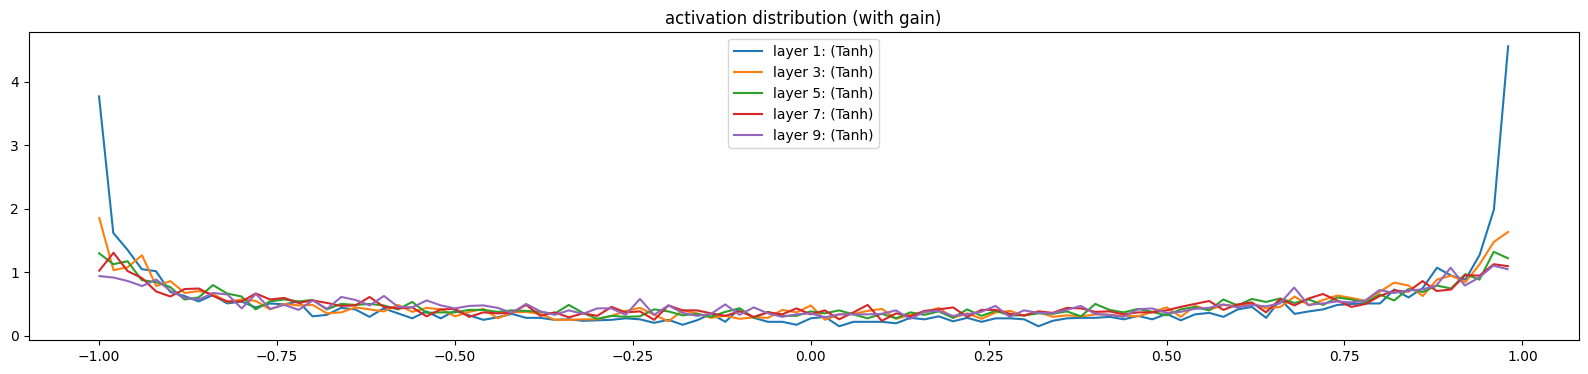

In [19]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t: torch.Tensor = layer.out
        # :>10, 分配 10 个字符的空间, 且右对齐
        # (t.abs() > 0.97 得到的仍是一个Tensor, Tensor 的元素都是 True, False, 转换为 floate 后求平均值
        print(
            f"layer {i}: ({layer.__class__.__name__:>10}): mean | {t.mean().item():+.4f}, std | {t.std().item():+.4f}, saturated | {((t.abs() > 0.97).float().mean() * 100):.4f}%"
        )

        hy, hx = torch.histogram(t, density=True)
        plt.plot(
            hx[:-1].detach(), hy.detach()
        )  # detach() 得到tensor 中的值, 因为 plot 不认识其中的 grad
        legends.append(f"layer {i}: ({layer.__class__.__name__})")  # 图例
plt.legend(legends)
plt.title("activation distribution (with gain)") # 有增益系数, mean, std 趋于稳定

`torch.histogram(t, density=True)` 对`t`中所有元素排序, 然后均匀的分到`100(默认值)`个`bin`中

横坐标的范围就是0~100, 纵坐标的就是在对应的bin范围中的元素的数量

比如`t`的元素的范围是`[0,1]`, 其中`[0.02,0.03]`这个`bin`的范围的元素数量是100, 那该点的纵坐标就是100

但是, 由于配置了`density=True`, 所以纵坐标的实际含义为概率密度

这幅图监控的是**前向传播**, 图中可以看到
- 仅`layer1`在两端分布的概率密度较高, 其它层的分布都比较均匀, 且没有集中在两端, 这说明神经元都比较有活力
- 分布曲线没有过于集中分布在某个范围, 这说明没有出现方差为0对的层, 这样的层意味着神经元没有学到任何知识, 意味着对任何输入都将输出相似的值

layer 1: (      Tanh): mean | +0.0000, std | +0.0004, saturated | 0.0000%
layer 3: (      Tanh): mean | -0.0000, std | +0.0004, saturated | 0.0000%
layer 5: (      Tanh): mean | -0.0000, std | +0.0003, saturated | 0.0000%
layer 7: (      Tanh): mean | -0.0000, std | +0.0003, saturated | 0.0000%
layer 9: (      Tanh): mean | -0.0000, std | +0.0003, saturated | 0.0000%


Text(0.5, 1.0, 'activation distribution (with gain)')

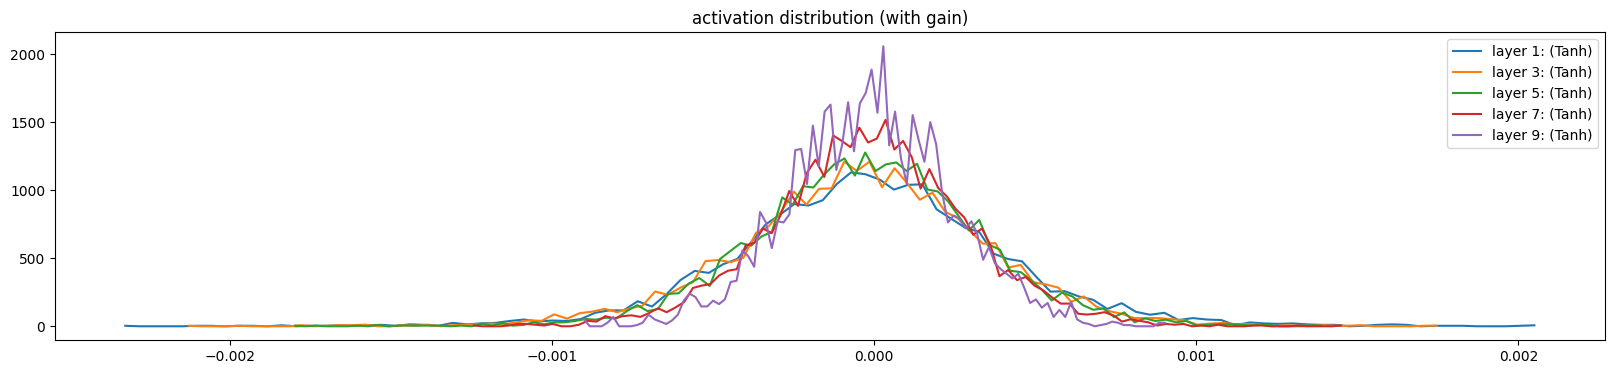

In [21]:
plt.figure(figsize=(20, 4))
legends = []
for i, layer in enumerate(layers[:-1]):
    if isinstance(layer, Tanh):
        t = layer.out.grad
        # :>10, 分配 10 个字符的空间, 且右对齐
        # (t.abs() > 0.97 得到的仍是一个Tensor, Tensor 的元素都是 True, False, 转换为 floate 后求平均值
        if t is None:
            break
        print(
            f"layer {i}: ({layer.__class__.__name__:>10}): mean | {t.mean().item():+.4f}, std | {t.std().item():+.4f}, saturated | {((t.abs() > 0.97).float().mean() * 100):.4f}%"
        )

        hy, hx = torch.histogram(t, density=True)
        plt.plot(
            hx[:-1].detach(), hy.detach()
        )  # detach() 得到tensor 中的值, 因为 plot 不认识其中的 grad
        legends.append(f"layer {i}: ({layer.__class__.__name__})")  # 图例
plt.legend(legends)
plt.title("activation distribution (with gain)") # 有增益系数, mean, std 趋于稳定

先明确几个概念

底层（Bottom Layer）= 浅层（Shallow Layer）：就是挨着输入数据最近的那几层（第 1 层、第 2 层）。它们负责提取最基础的特征（比如图片的边缘、文字的笔画）。

顶层（Top Layer）= 深层（Deep Layer）：就是挨着最终输出最近的那几层（第 9 层、第 10 层）。它们负责做最高级、最抽象的逻辑判断。

从图中可以看出没有出现梯度消失的问题, 即梯度集中分布在 0 附近, 如果这样, 那意味着该层的参数讲不会有什么变化, 同样意味着无法学习

weight shape |    list[27, 10], mean | +0.0002, std | +2.0402e-03, grad:data ratio | +2.0388e-03
weight shape |   list[30, 200], mean | -0.0000, std | +1.3242e-03, grad:data ratio | +4.3172e-03
weight shape |  list[200, 200], mean | -0.0000, std | +1.0965e-03, grad:data ratio | +9.3166e-03
weight shape |  list[200, 200], mean | -0.0000, std | +8.7956e-04, grad:data ratio | +7.4537e-03
weight shape |  list[200, 200], mean | -0.0000, std | +7.7020e-04, grad:data ratio | +6.4847e-03
weight shape |  list[200, 200], mean | -0.0000, std | +6.1992e-04, grad:data ratio | +5.2586e-03
weight shape |   list[200, 27], mean | -0.0000, std | +2.0990e-02, grad:data ratio | +2.6608e+00


Text(0.5, 1.0, 'weitht gradient distribution')

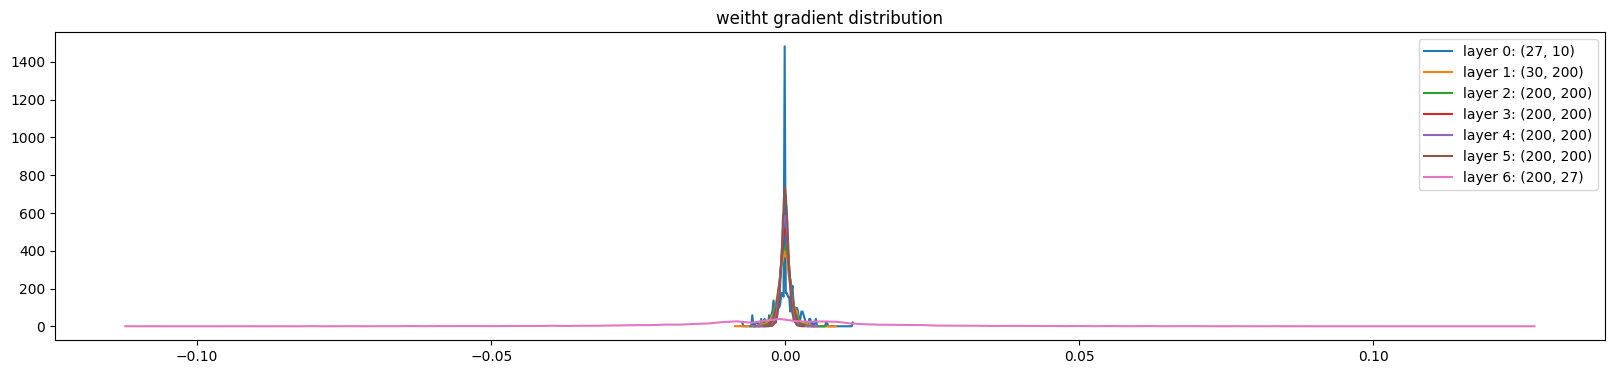

In [36]:
plt.figure(figsize=(20, 4))
legends = []
for i, p in enumerate(parameters):
    t = p.grad
    if t is None:
        break
    if (
        p.ndim == 2
    ):  # 这里过滤掉bias, 因为bias, 使图像更简洁, 主要还是由于对结果的影响很小
        print(
            f"weight shape | {(str(list[p.shape])):>15}, mean | {t.mean().item():+.4f}, std | {t.std().item():+.4e}, grad:data ratio | {(t.std() / p.std()).item():+.4e}"
        )

        hy, hx = torch.histogram(t, density=True)
        plt.plot(
            hx[:-1].detach(), hy.detach()
        )  # detach() 得到tensor 中的值, 因为 plot 不认识其中的 grad
        legends.append(f"layer {i}: {tuple(p.shape)}")  # 图例
plt.legend(legends)
plt.title("weitht gradient distribution")

工程经验法则——$1e^{-3}$ Rule（千分之一法则）

当我们将这个比值乘上所设置的学习率（比如 lr = 0.1）后：

$$\text{Update Ratio} = 0.1 \times \frac{t.\text{std}()}{p.\text{std}()}$$

这个最终算出来的比例，就是每一次参数更新的“步伐大小”。针对这个比例，有三条铁律：

完美健康（$\approx 10^{-3}$ 或 $0.001$）：这是炼丹师梦寐以求的比例。这意味着每一次前向和反向传播，网络大概会修改原有权重的 0.1%。步伐稳健，既能保证网络在稳步学习，又不会破坏之前学到的特征）。

濒临崩溃（$\approx 10^{-1}$ 或 $0.1$ 以上）：这意味着单次更新就要修改掉原有知识的 10% 到 100%！网络处于极度暴躁的震荡状态，Loss 会像过山车一样乱飞，永远找不到最优解。这时需要立刻调小学习率！

植物人状态（$\approx 10^{-5}$ 及以下）：每一次更新只修改原有知识的十万分之一。网络像蜗牛一样爬行，即使你训练几个星期，Loss 也降不下去。这通常是因为发生了严重的梯度消失，或者学习率设得实在太小了。

从上图中的数据可以看出一个问题

- 最后一层的`std`大约是倒数第二层的30倍, 由于学习率是全局统一的, 这意味着在绝对值的层面, 最后一层的学习速度是倒数第二层的30倍
- 但是在 grad:data ratio, 这里是相对值, 可以看到, 最后一层是倒数第二层的 1000 倍
- 原理类似, 大象向前走1m, 蚂蚁向前走0.9m,绝对值上相差0.1, 但是如果相对身体长度, 那相差的得有成千上万倍

在“Simple SGD setup（最朴素的梯度下降）”中，整个网络几百个层，只能共享同一个 learning_rate。

现在大楼的顶层（最后一层）步子是底层的 10 倍大，破坏力是 1000 倍。你作为炼丹师，该怎么设这个学习率？

如果你心疼底层，把 $\text{lr}$ 设大一点（比如 $0.1$）让底层能学到东西 $\rightarrow$ 最后一层直接原地爆炸，Loss 飞向无穷大（NaN）。

如果你害怕最后一层爆炸，把 $\text{lr}$ 设得极其微小（比如 $0.0001$） $\rightarrow$ 最后一层稳住了，但底层原本就只有 1/10 的梯度，现在彻底变成了死水，整个网络退化成了只有最后一层在工作的“单层感知机”。

这就是没有 BatchNorm 和高级优化器（如 Adam）时，深层网络在数学上几乎“不可训练”的根本原因。
